## Imports

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_graphviz
from sklearn.metrics import average_precision_score, recall_score, precision_score, precision_recall_curve, roc_auc_score, f1_score
from xgboost import XGBClassifier, plot_importance
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import xgboost
import shap
import graphviz
from catboost import CatBoostClassifier

                                                        
import warnings
warnings.filterwarnings('ignore')

# pd.set_option('max_columns', None)


## Preprocessing

In [4]:
df = pd.read_csv('limited_data_v3.csv')

In [5]:
i=1

for col in df.columns:
    df.rename(columns={col: 'col_' + str(i)}, inplace=True)
    i+=1

In [6]:
df.columns

Index(['col_1', 'col_2', 'col_3', 'col_4', 'col_5', 'col_6', 'col_7', 'col_8',
       'col_9', 'col_10', 'col_11', 'col_12', 'col_13', 'col_14', 'col_15',
       'col_16', 'col_17', 'col_18', 'col_19', 'col_20', 'col_21', 'col_22',
       'col_23', 'col_24', 'col_25', 'col_26', 'col_27', 'col_28', 'col_29',
       'col_30', 'col_31', 'col_32', 'col_33', 'col_34', 'col_35', 'col_36',
       'col_37', 'col_38', 'col_39', 'col_40', 'col_41', 'col_42', 'col_43',
       'col_44', 'col_45', 'col_46', 'col_47', 'col_48', 'col_49', 'col_50',
       'col_51', 'col_52', 'col_53'],
      dtype='object')

In [7]:
df.shape[0]

1261566

In [8]:
df.isna().sum()

col_1         0
col_2         0
col_3         0
col_4         0
col_5         0
col_6         0
col_7      8657
col_8         0
col_9         1
col_10        1
col_11        0
col_12        0
col_13        0
col_14        0
col_15        0
col_16        0
col_17        0
col_18        0
col_19     8657
col_20        0
col_21        0
col_22        0
col_23        0
col_24        0
col_25        0
col_26     7708
col_27     7708
col_28        0
col_29        0
col_30        5
col_31        5
col_32        5
col_33        5
col_34        5
col_35        5
col_36        5
col_37        0
col_38    23834
col_39    23273
col_40     6504
col_41        0
col_42        0
col_43        0
col_44        0
col_45        0
col_46        0
col_47        0
col_48        0
col_49        0
col_50        0
col_51        0
col_52        0
col_53        0
dtype: int64

In [9]:
df[['col_8', 'col_16', 'col_29', 'col_39', 'col_40']] \
.describe(percentiles=[.05, .25, .5, .75, .95, .99], include=['int', 'float']).round(0)

,col_8,col_16,col_29,col_39,col_40
count,1261566.0,1261566.0,1261566.0,1238293.0,1255062.0
mean,187.0,115.0,92.0,110.0,117.0
std,760.0,145.0,704.0,353.0,720.0
min,0.0,0.0,0.0,0.0,0.0
5%,0.0,1.0,2.0,1.0,1.0
25%,6.0,21.0,9.0,7.0,5.0
50%,22.0,79.0,19.0,21.0,15.0
75%,72.0,154.0,37.0,61.0,49.0
95%,827.0,354.0,315.0,498.0,402.0
99%,3548.0,674.0,1259.0,1781.0,1681.0


In [10]:
# Filtering NA values

df_lim = df[
            (df['col_16'] <= df['col_16'].quantile(q = 0.99)) &
            (df['col_39'] <= df['col_39'].quantile(q = 0.99)) &
            (df['col_40'] <= df['col_40'].quantile(q = 0.99)) 
]

df_lim.loc[df_lim['col_8'] > 1000, 'col_8'] = 1000
df_lim.loc[df_lim['col_29'] > 500, 'col_29'] = 500

df_lim['col_26'] = df_lim['col_26'].fillna(0)
df_lim['col_27'] = df_lim['col_27'].fillna(0)

df_lim['col_7'] = df_lim['col_7'].fillna(df_lim['col_7'] \
                                                                           .median())
df_lim['col_19'] = df_lim['col_19'].fillna(df_lim['col_19'] \
                                                                           .median())
df_lim['col_38'] = df_lim['col_38'].fillna(df_lim['col_38'] \
                                                                           .mean())
df_lim['col_39'] = df_lim['col_39'].fillna(df_lim['col_39'] \
                                                                           .median())
df_lim['col_40'] = df_lim['col_40'].fillna(df_lim['col_40'] \
                                                                           .mean())
df_lim.shape[0]


1196671

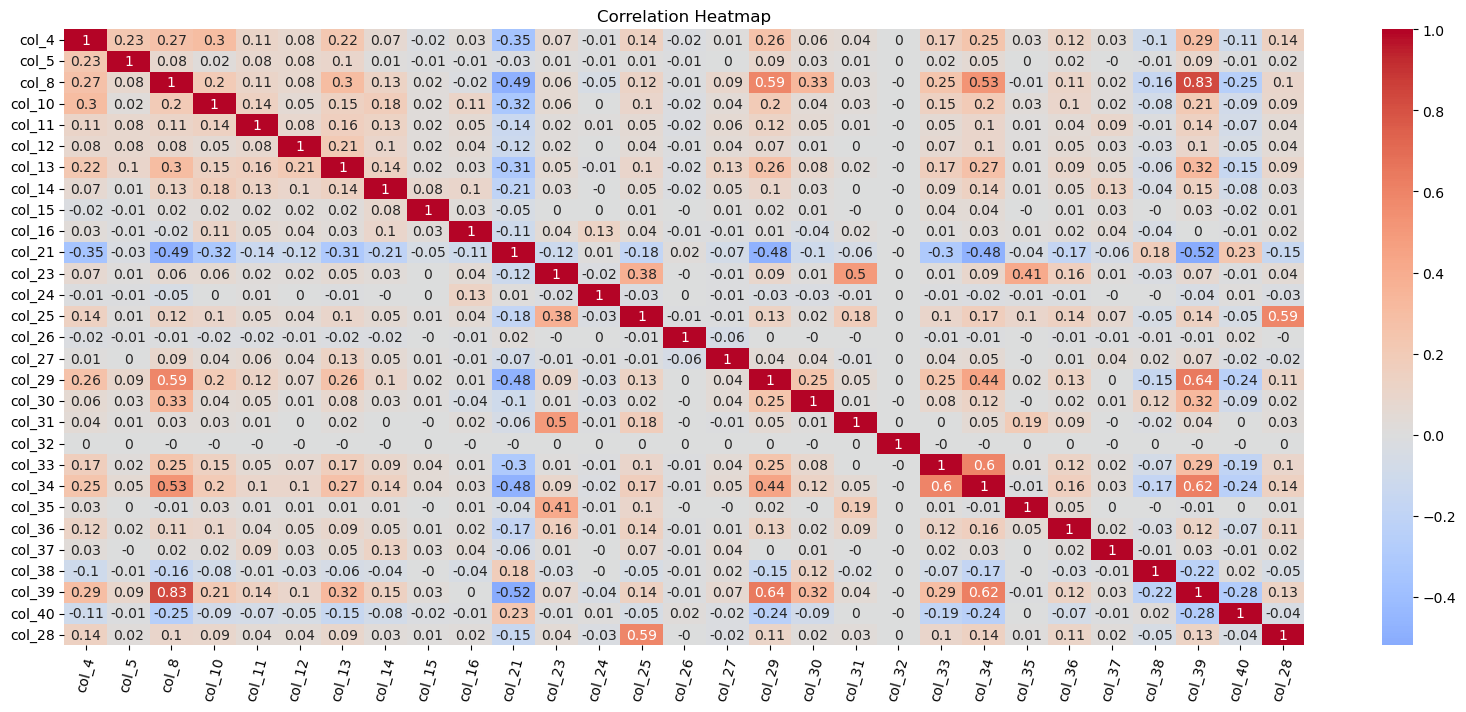

In [11]:
# Heatmap for correlations

corr_columns = ['col_4', 
                'col_5', 
                'col_8',
                'col_10',
                'col_11',
                'col_12', 
                'col_13', 
                'col_14',
                'col_15',
                'col_16', 
                'col_21', 
                'col_23',
                'col_24',
                'col_25',
                'col_26',
                'col_27',
                'col_29', 
                'col_30',
                'col_31', 
                'col_32',
                'col_33', 
                'col_34',
                'col_35', 
                'col_36', 
                'col_37',
                'col_38', 
                'col_39', 
                'col_40',
                'col_28']

df_lim_ml = df_lim[corr_columns]

corr_matrix = df_lim_ml.corr(method='spearman').round(2)

plt.figure(figsize=(20, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.xticks(rotation=75)
plt.title('Correlation Heatmap')
plt.show()


In [12]:
df_lim_ml_columns = ['col_4', 
                     'col_5', 
                     'col_10', 
                     'col_11', 
                     'col_12', 
                     'col_13', 
                     'col_14', 
                     'col_15',
                     'col_16', 
                     'col_21', 
                     'col_23',
                     'col_24',
                     'col_25', 
                     'col_26',
                     'col_27', 
                     'col_30',
                     'col_31',
                     'col_33', 
                     'col_34',
                     'col_37',
                     'col_38', 
                     'col_39', 
                     'col_40',
                     'col_28', 
                     'final_target']

factor_columns = ['col_43', 
                  'col_44',
                  'col_45', 
                  'col_46', 
                  'col_47', 
                  'col_48',
                  'col_49']

In [13]:
# Distribution of atribute

for v in ['Отличное', 'Новое с биркой', 'Б/у']:
    print(v)
    
    for i,f in enumerate(factor_columns):
        
        df_lim_factor = df_lim[df_lim['col_9'] == v].copy()
        df_lim_factor.loc[(df_lim_factor[f] == 1) & (df_lim_factor['col_53'] == 0), 'final_target'] = 0
        df_lim_factor.loc[(df_lim_factor['col_53'] == 1), 'final_target'] = 1
        
        df_lim_factor.dropna(subset=['final_target'], inplace=True)
    
        print(df_lim_factor['final_target'].value_counts(normalize=True).round(3)[0])

Отличное
0.395
0.234
0.112
0.248
0.24
0.318
0.131
Новое с биркой
0.339
0.358
0.086
0.187
0.193
0.396
0.112
Б/у
0.432
0.15
0.091
0.151
0.122
0.281
0.08


In [14]:
# Building a separate model for each factor in a loop

res_score_df = pd.DataFrame(columns=['factor', 'share_of_factor', 'avg_precision', 'recall', 'f1_score', 'feature_impact'])

for i,f in enumerate(factor_columns):
    
    df_lim_factor = df_lim.copy()
    df_lim_factor['final_target'] = np.nan
    df_lim_factor.loc[(df_lim_factor[f] == 1) & (df_lim_factor['col_53'] == 0), 'final_target'] = 0
    df_lim_factor.loc[df_lim_factor['col_53'] == 1, 'final_target'] = 1
    
    df_lim_factor.dropna(subset=['final_target'], inplace=True)

    share = df_lim_factor['final_target'].value_counts(normalize=True).round(3)[0]

    # print(df_lim_factor[(df_lim_factor[f] == 1) & (df_lim_factor['is_no_comm'] == 0)].shape[0])
    # print(df_lim_factor[df_lim_factor['is_no_comm'] == 1].shape[0])
    
    df_lim_factor_ml = df_lim_factor[df_lim_ml_columns]
    
    X = df_lim_factor_ml.drop('final_target', axis=1)
    y = df_lim_factor_ml['final_target']
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, 
                                                        stratify=X[['col_23', 'col_25']])


    # clf = RandomForestClassifier(max_depth=11,max_features=20,min_samples_leaf=3,min_samples_split=5, class_weight='balanced',
    #                              criterion='entropy',
    #                          random_state=42)

    clf = XGBClassifier(n_estimators=1000,learning_rate=0.01,max_depth=9, min_child_weight=5,objective='binary:logistic',
                             eval_metric='aucpr',early_stopping_rounds=50,
                             scale_pos_weight=df_lim_factor[df_lim_factor['final_target'] == 0].shape[0] / df_lim_factor[df_lim_factor['final_target'] == 1].shape[0],
                             subsample=0.8,
                             random_state=42)

    # clf = CatBoostClassifier(iterations=400, 
    #                         depth = 11,
    #                         loss_function='Logloss',
    #                         custom_loss= ['PRAUC', 'F1', 'Precision', 'Recall'],
    #                         verbose=False, 
    #                         auto_class_weights='Balanced', random_state=42)
    
    # tree = clf.fit(X_train, y_train)

    tree = clf.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    
    predicts = clf.predict(X_test)
    predicts_proba = clf.predict_proba(X_test)
    
    aps = average_precision_score(y_test, predicts_proba[:,1])
    rs = recall_score(y_test, predicts)
    f1 = f1_score(y_test, predicts)

    print(aps, rs, f1)

    print('======================================================')
    print(f, '\n')
    features_df = pd.DataFrame(data=tree.feature_importances_, index=X_train.columns, columns=['Feature']) \
        .sort_values(by='Feature', ascending=False)
    fimp = []
    for _, row in features_df.iterrows():
        # if row[0] >= 1:
        if row[0] >= 0.01:
            print(row.name + ' ' + str(np.round(row[0], 3)))
            fimp.append(row.name + ' ' + str(np.round(row[0], 3)))
    fimp = str(fimp)
    
    new_row = pd.DataFrame({'factor': f,'share_of_factor': share, 'avg_precision': aps,'recall': rs, 'f1_score': f1, 'feature_impact':fimp},
                           index=[i])
    res_score_df = pd.concat([res_score_df, new_row])


0.7505633233714456 0.566822964574967 0.6338275507388174
col_43 

col_26 0.148
col_21 0.119
col_5 0.11
col_24 0.109
col_11 0.062
col_12 0.043
col_10 0.043
col_30 0.038
col_37 0.033
col_34 0.033
col_4 0.028
col_23 0.027
col_25 0.024
col_14 0.023
col_40 0.022
col_16 0.021
col_31 0.017
col_33 0.017
col_13 0.015
col_27 0.014
col_39 0.014
col_28 0.014
col_38 0.013
col_15 0.011
0.8907760251393573 0.7350266541235497 0.7915146618105512
col_44 

col_4 0.684
col_24 0.049
col_11 0.042
col_5 0.03
col_26 0.028
col_37 0.02
col_10 0.017
col_14 0.013
col_12 0.013
col_16 0.012
0.9516291346385208 0.6666965918910124 0.7805038263211482
col_45 

col_24 0.112
col_5 0.101
col_37 0.093
col_26 0.061
col_14 0.054
col_27 0.051
col_11 0.043
col_16 0.042
col_30 0.038
col_12 0.035
col_23 0.033
col_21 0.033
col_4 0.032
col_25 0.032
col_10 0.03
col_34 0.029
col_15 0.027
col_31 0.025
col_13 0.024
col_33 0.023
col_39 0.022
col_40 0.022
col_38 0.019
col_28 0.018
0.9067659928195873 0.6637086628324946 0.7589723827874116
co

In [15]:
# Final Importances

res_score_df.round(3)

,factor,share_of_factor,avg_precision,recall,f1_score,feature_impact
0,col_43,0.382,0.751,0.567,0.634,"['col_26 0.148', 'col_21 0.119', 'col_5 0.11',..."
1,col_44,0.233,0.891,0.735,0.792,"['col_4 0.684', 'col_24 0.049', 'col_11 0.042'..."
2,col_45,0.093,0.952,0.667,0.781,"['col_24 0.112', 'col_5 0.101', 'col_37 0.093'..."
3,col_46,0.187,0.907,0.664,0.759,"['col_24 0.151', 'col_26 0.093', 'col_14 0.091..."
4,col_47,0.174,0.913,0.631,0.740,"['col_24 0.155', 'col_11 0.132', 'col_26 0.094..."
5,col_48,0.317,0.818,0.674,0.723,"['col_4 0.546', 'col_5 0.058', 'col_11 0.057',..."
6,col_49,0.102,0.951,0.695,0.799,"['col_5 0.531', 'col_4 0.095', 'col_24 0.042',..."


## Calculation automation

In [16]:
final_score_df = pd.DataFrame(columns=df_lim_ml_columns, data=np.empty((7, 25)))

final_score_df.loc[:,:] = np.nan

final_score_df.index = factor_columns


In [17]:
final_dict = {}

for f in factor_columns:
    final_dict[f] = {}
    for col in df_lim_ml_columns:
        final_dict[f][col] = []
        

In [18]:
for i,f in enumerate(factor_columns):
        
        df_lim_factor = df_lim.copy()
        df_lim_factor.loc[(df_lim_factor[f] == 1) & (df_lim_factor['col_53'] == 0), 'final_target'] = 0
        df_lim_factor.loc[(df_lim_factor['col_53'] == 1), 'final_target'] = 1
        
        df_lim_factor.dropna(subset=['final_target'], inplace=True)
    
        share = df_lim_factor['final_target'].value_counts(normalize=True).round(3)[0]
        
        df_lim_factor_ml = df_lim_factor[df_lim_ml_columns]
        
        X = df_lim_factor_ml.drop('final_target', axis=1)
        y = df_lim_factor_ml['final_target']
        
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, 
                                                            stratify=X[['col_23', 'col_25']])
    
        clf = XGBClassifier(n_estimators=1000,learning_rate=0.01,max_depth=9, min_child_weight=5,objective='binary:logistic',
                                 eval_metric='aucpr',early_stopping_rounds=50,
                                 scale_pos_weight=df_lim_factor[df_lim_factor['final_target'] == 0].shape[0] / df_lim_factor[df_lim_factor['final_target'] == 1].shape[0],
                                 subsample=0.8,
                                 random_state=42)
    
        tree = clf.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
        
        features_df = pd.DataFrame(data=tree.feature_importances_, index=X_train.columns, columns=['Feature']) \
            .sort_values(by='Feature', ascending=False)
        fimp = []
        for _, row in features_df.iterrows():
            # if row[0] >= 1:
            if row[0] >= 0.01:
                # print(row.name + ' ' + str(np.round(row[0], 3)))
                final_dict[f][row.name].append(np.round(row[0], 3))

In [19]:
res_df = pd.DataFrame(final_dict).transpose()

def calculate_mean(cell):
    return np.mean(cell)

df_mean = res_df.applymap(calculate_mean)

In [20]:
# Adding weights for factors distrib. in total data

df_mean.loc['col_43', :] = df_mean.loc['col_43', :] * 0.382
df_mean.loc['col_44', :] = df_mean.loc['col_44', :] * 0.233
df_mean.loc['col_45', :] = df_mean.loc['col_45', :] * 0.093
df_mean.loc['col_46', :] = df_mean.loc['col_46', :] * 0.187
df_mean.loc['col_47', :] = df_mean.loc['col_47', :] * 0.174
df_mean.loc['col_48', :] = df_mean.loc['col_48', :] * 0.317
df_mean.loc['col_49', :] = df_mean.loc['col_49', :] * 0.102

In [21]:
df_mean.sum().sort_values(ascending=False)

col_4           0.372196
col_5           0.147235
col_24          0.138495
col_26          0.122195
col_11          0.092701
col_21          0.065550
col_37          0.058884
col_10          0.049473
col_14          0.047740
col_12          0.045009
col_16          0.037074
col_30          0.031733
col_23          0.031298
col_25          0.029348
col_34          0.028593
col_40          0.022703
col_31          0.019482
col_27          0.018759
col_13          0.016763
col_39          0.015710
col_33          0.015479
col_15          0.014706
col_28          0.013172
col_38          0.012296
final_target    0.000000
dtype: float64

In [22]:
df_mean.sum().sort_index()

col_10          0.049473
col_11          0.092701
col_12          0.045009
col_13          0.016763
col_14          0.047740
col_15          0.014706
col_16          0.037074
col_21          0.065550
col_23          0.031298
col_24          0.138495
col_25          0.029348
col_26          0.122195
col_27          0.018759
col_28          0.013172
col_30          0.031733
col_31          0.019482
col_33          0.015479
col_34          0.028593
col_37          0.058884
col_38          0.012296
col_39          0.015710
col_4           0.372196
col_40          0.022703
col_5           0.147235
final_target    0.000000
dtype: float64

In [23]:
# Total aggregations info

total_aggr_df = pd.DataFrame(columns=df_lim_ml_columns)

for i,f in enumerate(factor_columns):
    
    df_lim_factor = df_lim.copy()
    df_lim_factor.loc[(df_lim_factor[f] == 1) & (df_lim_factor['col_53'] == 0), 'final_target'] = 0
    df_lim_factor.loc[(df_lim_factor['col_53'] == 1), 'final_target'] = 1
    
    df_lim_factor.dropna(subset=['final_target'], inplace=True)
    aggr_df = df_lim_factor.groupby(['final_target'])[df_lim_ml_columns].mean()
    new_row = pd.DataFrame(data=aggr_df.iloc[:1,:])
    total_aggr_df = pd.concat([total_aggr_df, new_row])

factor_columns.append('col_53')
total_aggr_df = pd.concat([total_aggr_df, pd.DataFrame(data=aggr_df.iloc[1:,:])], ignore_index=True)
total_aggr_df.index = factor_columns

In [24]:
df[['col_16', 'col_29', 'col_39', 'col_40']] \
.describe(percentiles=[.05, .25, .5, .75, .95, .99], include=['int', 'float']).round(0)

,col_16,col_29,col_39,col_40
count,1261566.0,1261566.0,1238293.0,1255062.0
mean,115.0,92.0,110.0,117.0
std,145.0,704.0,353.0,720.0
min,0.0,0.0,0.0,0.0
5%,1.0,2.0,1.0,1.0
25%,21.0,9.0,7.0,5.0
50%,79.0,19.0,21.0,15.0
75%,154.0,37.0,61.0,49.0
95%,354.0,315.0,498.0,402.0
99%,674.0,1259.0,1781.0,1681.0


## Model for one factor

In [25]:
# Same operations. Testing one separate model for one factor

df_lim = df[
            (df['col_17'] >= 500) & 
            (df['col_17'] < 10000) &
            (df['col_16'] <= df['col_16'].quantile(q = 0.99)) &
            (df['col_39'] <= df['col_39'].quantile(q = 0.99)) &
            (df['col_40'] <= df['col_40'].quantile(q = 0.99)) 
]

df_lim.loc[df_lim['col_8'] > 1000, 'col_8'] = 1000
df_lim.loc[df_lim['col_29'] > 500, 'col_29'] = 500

df_lim['col_26'] = df_lim['col_26'].fillna(0)
df_lim['col_27'] = df_lim['col_27'].fillna(0)

df_lim['col_7'] = df_lim['col_7'].fillna(df_lim['col_7'] \
                                                                           .median())
df_lim['col_19'] = df_lim['col_19'].fillna(df_lim['col_19'] \
                                                                           .median())
df_lim['col_38'] = df_lim['col_38'].fillna(df_lim['col_38'] \
                                                                           .mean())
df_lim['col_39'] = df_lim['col_39'].fillna(df_lim['col_39'] \
                                                                           .median())
df_lim['col_40'] = df_lim['col_40'].fillna(df_lim['col_40'] \
                                                                           .mean())
df_lim.shape[0]


851633

In [26]:
df_lim_ml_columns = ['col_4', 
                     'col_5', 
                     'col_10', 
                     'col_11', 
                     'col_12', 
                     'col_13', 
                     'col_14', 
                     'col_15',
                     'col_16', 
                     'col_21', 
                     'col_23',
                     'col_24',
                     'col_25', 
                     'col_26',
                     'col_27', 
                     'col_30',
                     'col_31',
                     'col_33', 
                     'col_34',
                     'col_37',
                     'col_38', 
                     'col_39', 
                     'col_40',
                     'col_28', 
                     'final_target']

factor_columns = ['col_43', 
                  'col_44',
                  'col_45', 
                  'col_46', 
                  'col_47', 
                  'col_48',
                  'col_49']

In [27]:
df_lim_factor = df_lim.copy()
df_lim_factor.loc[(df_lim_factor['col_43'] == 1) & (df_lim_factor['col_53'] == 0), 'final_target'] = 0
df_lim_factor.loc[(df_lim_factor['col_53'] == 1), 'final_target'] = 1

df_lim_factor.dropna(subset=['final_target'], inplace=True)

share = df_lim_factor['final_target'].value_counts(normalize=True).round(3)[0]

df_lim_factor_ml = df_lim_factor[df_lim_ml_columns]

X = df_lim_factor_ml.drop('final_target', axis=1)
y = df_lim_factor_ml['final_target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, 
                                                    stratify=X[['col_23', 'col_25']])

CBCl = XGBClassifier(iterations=200, 
                            depth = 11,
                            loss_function='Logloss',
                            custom_loss= ['PRAUC', 'F1', 'Precision', 'Recall'],
                            verbose=False, 
                            auto_class_weights='Balanced')

tree = CBCl.fit(X_train, y_train)

predicts = CBCl.predict(X_test)
predicts_proba = CBCl.predict_proba(X_test)

aps = average_precision_score(y_test, predicts_proba[:,1])
rs = recall_score(y_test, predicts)
f1 = f1_score(y_test, predicts)



In [28]:
features_df = pd.DataFrame(data=tree.feature_importances_, index=X_train.columns, columns=['Feature']) \
    .sort_values(by='Feature', ascending=False)
fimp = []
for _, row in features_df.iterrows():
    if row[0] >= 0.01:
        print(row.name + ' ' + str(np.round(row[0], 3)))
        fimp.append(row.name + ' ' + str(np.round(row[0], 3)))
fimp = str(fimp)

col_24 0.2
col_26 0.158
col_21 0.157
col_5 0.06
col_30 0.055
col_34 0.047
col_11 0.034
col_10 0.031
col_4 0.028
col_12 0.025
col_16 0.024
col_23 0.02
col_37 0.019
col_25 0.019
col_27 0.019
col_40 0.018
col_39 0.015
col_13 0.014
col_33 0.014
col_14 0.013
col_38 0.011
